# 💎 Diamond Price Prediction
### Support Vector Regression (SVR) — Diamonds Dataset

Importing libaries

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Importing Dataset

In [114]:
dataset = pd.read_csv("diamonds.csv")
dataset.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Encoding Categorical Features

In [115]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset["cut"] = le.fit_transform(dataset["cut"])
dataset["color"] = le.fit_transform(dataset["color"])
dataset["clarity"] = le.fit_transform(dataset["clarity"])

dataset.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


Feature Selection

In [116]:
correlation = dataset.corr()["price"].sort_values(ascending=False)
print(correlation)

features = ["carat", "x", "y", "z"]
target = ["price"]

x = dataset[features]
y = dataset[target]

price         1.000000
carat         0.921591
x             0.884435
y             0.865421
z             0.861249
color         0.172511
table         0.127134
cut           0.039860
depth        -0.010647
clarity      -0.071535
Unnamed: 0   -0.306873
Name: price, dtype: float64


Spliting Dataset into Training set and Test set

In [117]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Feature Scaling

In [118]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()

x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

y_train = sc_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = sc_y.transform(y_test.values.reshape(-1, 1)).ravel()

Training Support Vector Regression Model

In [119]:
from sklearn.svm import SVR
regressor = SVR(kernel='rbf', C=100, epsilon=0.1)
regressor.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


Model Evaluation

In [120]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred = regressor.predict(x_test)

#  Inverse transform to get actual prices
y_pred_actual = sc_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
y_test_actual = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mean_price = y_test_actual.mean()

print(f"R2 Score: {r2_score(y_test_actual, y_pred_actual):.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"Mean Diamond Price: {mean_price:.2f}")
print(f"RMSE as % of Mean Price: {(rmse / mean_price) * 100:.2f}%")

R2 Score: 0.8817
RMSE: 1371.56
Mean Diamond Price: 3906.04
RMSE as % of Mean Price: 35.11%


Visualizing the Result

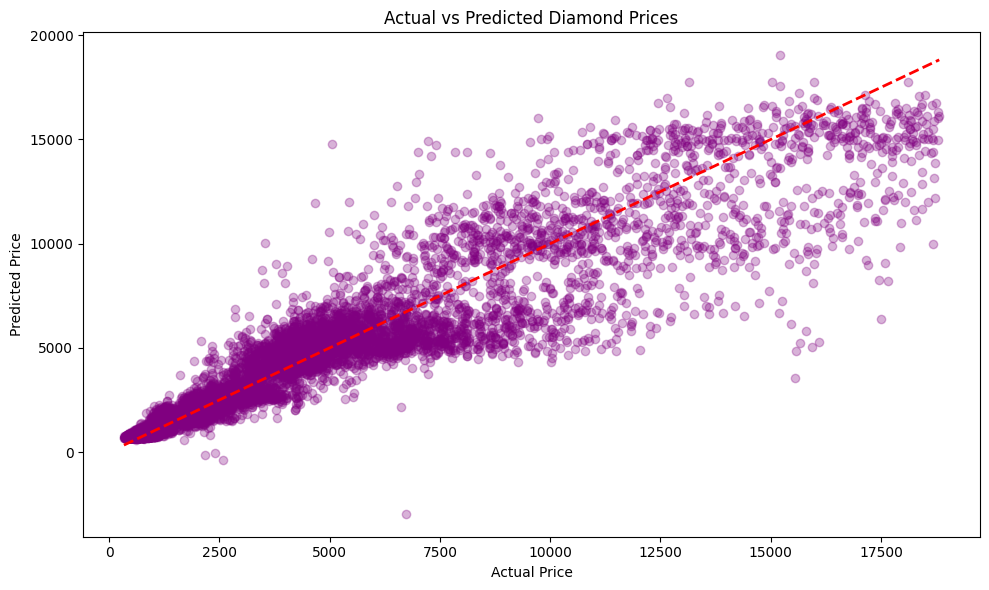

In [121]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.3, color='purple')
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Diamond Prices')
plt.tight_layout()
plt.show()

Prediction Error Distribution

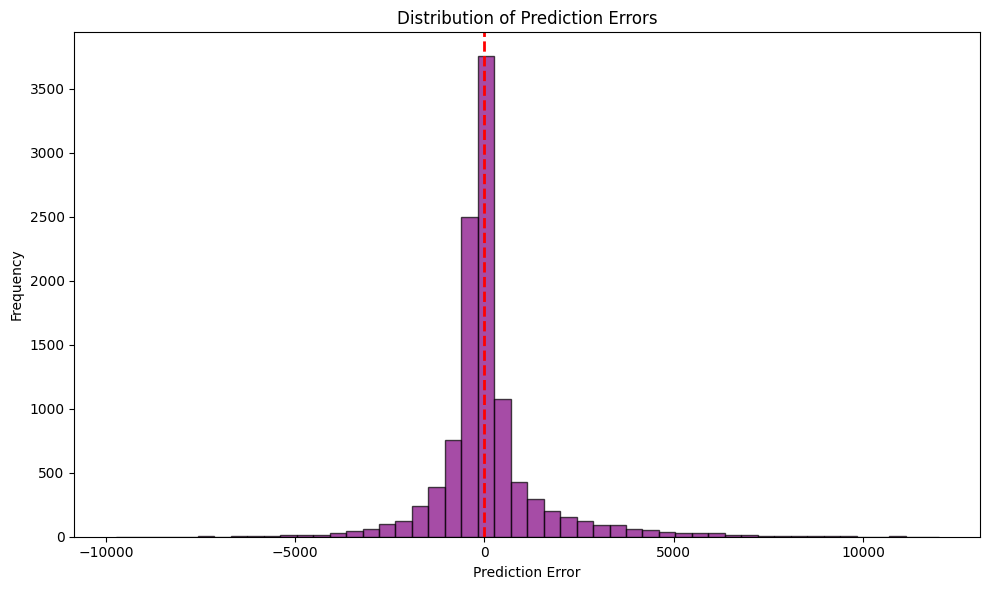

In [122]:
errors = y_test_actual - y_pred_actual

plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.tight_layout()
plt.show()